<a href="https://colab.research.google.com/github/kasettisiva/R_training_summer_workshop_2026/blob/main/Introduction_to_R_AI_Era_ClaudeGenerated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to R in the Age of AI**
## **LONI Summer Workshop 2026**



## **Outline**

0. What is R
1. Why R Still Matters
2. Setup & Basic Syntax
3. Data Structures That You'll Actually Use
4. Data Wrangling with Real Data
5. Visualization with ggplot2
6. Statistical Thinking
7. Your First ML Workflow
8. Working with AI: Prompting, Verifying, Fixing
9. Wrap up

## **What is R**

* R is a programming language for statistical computing
  * Importing, storing, exporting and manipulating data
  * Conducting statistical analyses
  * Displaying the results by tables, graphs, etc.
* R is also a software environment for the development and implementation of new algorithms.
  * Many graphical user interface to R both free and commercial (e.g. Rstudio and Microsoft R Open).
* R is being used by many disciplines
  * [A collection of repositories of R codes categorized by discipline](https://github.com/lsuhpchelp/r_collection)

## **Run This First**

Install and load all packages needed for the workshop.

**DO NOT CHANGE THE RUNTIME BECAUSE YOU WON'T BE ABLE TO CHANGE IT BACK!**

In [ ]:
install.packages(c("ggplot2", "dplyr", "tidyr", "rpart", "rpart.plot", "Metrics"))

library(ggplot2)
library(dplyr)
library(tidyr)
library(rpart)
library(rpart.plot)
library(Metrics)
print("All packages loaded.\n")

---

> **Workshop philosophy:**

> Now a days, AI tools like ChatGPT, Gemini or Claude, or other LLMs can now write R code for you.
> That makes understanding R *more* important, not less — you need to read, verify, and debug
> what AI produces. This workshop teaches you how to become collaborate with AI, not just using it as a passive user.

# **1 · Why R Still Matters**

**The AI question everyone is thinking:** *"If ChatGPT can write R code, why learn R?"*

Here's the honest answer:

| What AI is good at | What YOU still need |
|---|---|
| Writing boilerplate code | Understanding what the code does |
| Suggesting packages | Knowing whether the approach is valid |
| Fixing syntax errors | Catching logic errors and wrong assumptions |
| Generating plots | Interpreting what the plot means |
| Explaining concepts | Deciding which method fits your data |

AI is a *coding assistant*, not actually doing analysis or taking decisions.

### **R's unique strengths**
- **Statistical rigor** — reproducible, peer-reviewed methods built in  
> R was created by statisticians, so methods like t.test(), lm(), and anova() are built directly into the language and match exactly what academic papers use. You get trustworthy, citable results out of the box.
- **Visualization** — ggplot2 grammar is unmatched for publication figures
> ggplot2 lets you build any statistical plot by layering simple components, and the output looks publication-ready without extra formatting. No other visualization library matches it for statistical graphics specifically.
- **Bioinformatics / genomics** — Bioconductor has no Python equivalent
> Bioconductor is a curated collection of 2,000+ R packages built by life sciences researchers for biological data — RNA-seq, single-cell analysis, genome annotation, and more. Python simply doesn't have an equivalent ecosystem for this domain.
- **RMarkdown / Quarto** — narrative + code + output in one document
> Instead of writing your analysis in R and your report separately, you write both in one file. When the data changes, you re-run the document and every table, number, and plot updates automatically.  
- **HPC integration** — submit parallel R jobs to SLURM just like any other workflow
> An R script runs from the command line with Rscript myscript.R, so SLURM treats it like any other job. You can submit it with sbatch, run hundreds of copies as a job array, and use multiple cores within each job — no special setup required.

> **Key mindset shift:** R + AI together is more powerful than either alone.
> Your job is to direct the collaboration intelligently.

---

# **2 · How to Run R Code**

There are (at least) three options to run R codes:
1. Google Colaboratory
2. Rstudio (or Microsoft R Open or any other IDE)
3. HPC clusters

### **1. Google Colaboratory**

This is what we are using right now. It is the most convenient - browser-based and no setup is needed. The only thing you need is a Google account. In the meanwhile, we don't have much control on the environment. For instance, we can't choose which version to use and have very limited control on where the data is stored.

### **2. Rstudio (or Microsoft R Open or any other IDE that supports R)**

![Rstudio screen shot](https://support.rstudio.com/hc/article_attachments/115020357707/Screen_Shot_2017-08-24_at_1.22.05_PM.png)

Rstudio is an intergrated development environment (IDE) for R.

* Free to use: [Rstudio website](https://www.rstudio.com/)
* Its user interface is similar to IDEs, dividing the screen into panes
  * Source code editor
  * Console
  * Workspace
  * Others (help message, plot etc.)
* Rstudio in a desktop environment is better suited for code development and/or a limited number of small jobs.

Rstudio also provides a collection of very useful cheat sheets about how to use R [here](https://www.rstudio.com/resources/cheatsheets/).

### **3. HPC Clusters**

The HPC clusters are good for resource‐demanding workloads, e.g. resource-intense tasks or many small tasks.

## **2.1 Basic Syntax**

Assignment and naming

R uses <- by convention (you'll see both <- and = in the wild).

In [ ]:
# R convention: use <- for assignment
gene_count <- 24000
sample_id  <- "SRR123456"
is_paired  <- TRUE

# Print values
gene_count
sample_id
is_paired

## **2.2 Arithmetic and comparisons**
Basic arithematic operators: +, -, *, /, ^

In [ ]:
# Basic arithmetic
2 + 2
3.14 * 10^2
sqrt(144)

# Comparisons return TRUE/FALSE — critical for filtering data
gene_count > 20000
sample_id == "SRR999"

## **2.3 Getting help**
Getting help is straightforward in R.

For information about specific functions or objects, use `?<name of funciton>`.

```r
?mean           # help page for a function
??normalization  # search for keyword across all installed packages
```

> 💡 **Tip:** If the help page is confusing, paste the function signature into Claude or ChatGPT and ask "explain this in plain English with an example."

---

# **3 · Data Structures That You'll Actually Use**

Now let's look at the data objects in R. They are:

* Vectors: elements of same class, one dimension
* Matrices: elements of same class, two dimensions
* Arrays: elements of same class, 2+ dimensions
* Lists: elements can be any objects
* Data frames: “datasets” where columns are variables and rows are observations

> We focus on the two you'll encounter 95% of the time:
**vectors** and **data frames**.

### **3.1 Vectors**
Vectors are one-dimentional arrays that contain
elements of the **same** data type.

Vectors can be constructed by
* The `c()` funtion (concatenate):

In [ ]:
# Numeric vector — e.g. expression values for 5 genes
expr <- c(12.4, 0.3, 88.1, 45.0, 7.7)
expr

# Character vector — gene names
genes <- c("BRCA1", "TP53", "MYC", "EGFR", "KRAS")
genes

# Logical vector — which genes are highly expressed (> 40)?
high_expr <- expr > 40
high_expr

# Use that logical vector to filter
genes[high_expr]   # <- This pattern is everywhere in R

[1] 12.4  0.3 88.1 45.0  7.7

[1] "BRCA1" "TP53"  "MYC"   "EGFR"  "KRAS"

[1] FALSE FALSE  TRUE  TRUE FALSE

[1] "MYC"  "EGFR"

### **3.2 Data Frames — the workhorse of R**

Data frames are used to store tabular data.
* They are a special type of **lists**, where each element is a R vector ("column" or "variable") and has to be of the same length.
* The elements (columns) can be of different classes.
* Data frames have special attributes such as row.names.
* Data frames can be created by reading data files, using functions such as `read.table()` or `read.csv()`.


Data frames can be created directly by using the `data.frame()` function.

In [ ]:
# Build a small data frame from scratch
gene_df <- data.frame(
  gene    = genes,
  expr    = expr,
  is_high = high_expr,
  stringsAsFactors = FALSE
)

gene_df

# Basic inspection
nrow(gene_df)
ncol(gene_df)
str(gene_df)

gene,expr,is_high
<chr>,<dbl>,<lgl>
BRCA1,12.4,FALSE
TP53,0.3,FALSE
MYC,88.1,TRUE
EGFR,45.0,TRUE
KRAS,7.7,FALSE


[1] 5

[1] 3

'data.frame':	5 obs. of  3 variables:
 $ gene   : chr  "BRCA1" "TP53" "MYC" "EGFR" ...
 $ expr   : num  12.4 0.3 88.1 45 7.7
 $ is_high: logi  FALSE FALSE TRUE TRUE FALSE


### **3.3 Subsetting — three ways to slice**

Subsetting means selecting specific parts of your data like a vector, data frame, or list in R.

You can subset:

* By column name
* By position `[row, col]`
* By condition

In [ ]:
# 1. By column name (most readable)
gene_df$expr

# 2. By position [row, col]
gene_df[1, ]      # first row
gene_df[, 2]      # second column

# 3. By condition
gene_df[gene_df$expr > 40, ]

> **⚠️ Watch out:** When AI generates subsetting code it often mixes these styles.
> If you see `df[df$x > 5, "y"]`, that's style 2 + 3 combined — read it as:
> *"rows where x > 5, only column y"*.

---

# **4· Data Wrangling with Real Data**

Data wrangling means preparing and transforming data so it is easier to analyze.

In real data analysis, we often need to:

- select specific rows or columns
- filter data based on conditions
- check missing values and duplicates
- create new columns
- sort data
- summarize data

We'll use the built-in `mtcars` dataset (car performance specs) — small enough to understand
instantly, realistic enough to show real patterns.


In [ ]:
# Load and preview
data(mtcars)
head(mtcars)

### **Data Cleaning**

Data cleaning focuses on fixing problems in the data.

Examples:

- checking missing values
- removing duplicate rows
- renaming columns
- fixing incorrect values

**Missing Values**

Missing values (missing data) are a common problem in data science. It can have a significant effect on the conclusions that can be drawn from the data. Therefore, R has many functions and packages that deal with the missing value problem.

For example, the `complete.cases` function will scan a dataframe and return a logical vector where the rows without missing values are TRUE and those with missing values FALSE.

In [ ]:
# In the airquality dataset we have used for Exercise 1, there are some missing values.
complete.cases(airquality)

The simplest way of dealing with missing values is to drop all rows with missing values (not necessarily the best way!).

In [ ]:
airquality[complete.cases(airquality),]

**Duplicate Values**

In [ ]:
duplicated(airquality)
airquality[!duplicated(airquality), ]

### **Data Manipulation**

Data manipulation focuses on selecting, changing, organizing, and summarizing data.

Examples:

- creating new columns
- subsetting
- filtering rows
- selecting columns
- sorting rows
- summarizing data

**Creating New Columns**

To add columns/variables to a dataframe, we can simply use the assignment operation.

In [ ]:
gene_df$expr_category <- ifelse(gene_df$expr > 40, "High", "Low")
gene_df

In [ ]:
gene_df$very_high <- gene_df$expr > 80
gene_df

In [ ]:
gene_df$expr_norm <- gene_df$expr / max(gene_df$expr)
gene_df

**Subsetting**

Subsetting means selecting specific parts of your data like a vector, data frame, or list in R.

You can subset:

* By column name
* By position `[row, col]`
* By condition

In [ ]:
# 1. By column name (most readable)
gene_df$expr

# 2. By position [row, col]
gene_df[1, ]      # first row
gene_df[, 2]      # second column

# 3. By condition
gene_df[gene_df$expr > 40, ]

We'll use **dplyr** — the tidyverse data wrangling package.
Its verbs (`filter`, `select`, `mutate`, `summarize`, `arrange`) map almost directly
to SQL.

In [ ]:
# --- dplyr verbs ---

# filter(): keep rows matching a condition
efficient <- filter(mtcars, mpg > 25)
efficient

# select(): keep only certain columns
select(mtcars, mpg, cyl, hp)

# mutate(): add or transform a column
mtcars <- mutate(mtcars, kpl = mpg * 0.425)  # miles/gallon → km/litre
head(mtcars[, c("mpg", "kpl")])

In [ ]:
# arrange(): sort rows
arrange(mtcars, desc(mpg))   # best fuel efficiency first

**The pipe `%>%` (or `|>`)**

The pipe chains operations left-to-right — reads like a recipe.

```r
data %>%
  step1() %>%
  step2() %>%
  step3()
```

> Read them top-to-bottom: each step's output becomes the next step's input.

In [ ]:
# summarize() + group_by(): aggregate statistics by group
mtcars %>%
  group_by(cyl) %>%
  summarize(
    n         = n(),
    mean_mpg  = round(mean(mpg), 1),
    mean_hp   = round(mean(hp), 1),
    mean_wt   = round(mean(wt), 2)
  )

**Quick exercise**

Using the code above as a template, find the average horsepower (`hp`) and weight (`wt`)
for cars with 4 and 6 cylinders only (exclude `cyl == 8`).

In [ ]:
# Your code here
# Hint: chain filter() before group_by()

In [ ]:
#@title Solution { display-mode: "form" }
mtcars %>%
  filter(cyl != 8) %>%
  group_by(cyl) %>%
  summarize(
    n        = n(),
    mean_mpg = round(mean(mpg), 1),
    mean_hp  = round(mean(hp), 1),
    mean_wt  = round(mean(wt), 2)
  )

---

# **5 · Visualization with ggplot2**

ggplot2 uses a **grammar of graphics**: every plot is built from layers.

```
ggplot(data, aes(x = ..., y = ..., color = ...))  # canvas + mapping
  + geom_*()                                        # geometric layer
  + labs()                                          # labels
  + theme_*()                                       # styling
```

Once you know this grammar, you can read any ggplot2 code AI generates.

In [ ]:
# Scatter plot: weight vs fuel efficiency, colored by cylinders
ggplot(mtcars, aes(x = wt, y = mpg, color = factor(cyl))) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE) +  # regression line per group
  labs(
    title = "Fuel Efficiency vs Weight",
    subtitle = "By number of cylinders",
    x = "Weight (1000 lbs)",
    y = "Miles per Gallon",
    color = "Cylinders"
  ) +
  theme_minimal()

In [ ]:
# Box plot: distribution of mpg by cylinder count
ggplot(mtcars, aes(x = factor(cyl), y = mpg, fill = factor(cyl))) +
  geom_boxplot(alpha = 0.7, outlier.shape = 21) +
  labs(title = "MPG Distribution by Cylinder Count",
       x = "Cylinders", y = "Miles per Gallon") +
  theme_bw() +
  theme(legend.position = "none")

In [ ]:
# Histogram with density overlay
ggplot(mtcars, aes(x = mpg)) +
  geom_histogram(aes(y = after_stat(density)), bins = 12,
                 fill = "#4E79A7", color = "white", alpha = 0.8) +
  geom_density(color = "#E15759", linewidth = 1.2) +
  labs(title = "Distribution of Fuel Efficiency",
       x = "Miles per Gallon", y = "Density") +
  theme_minimal()

> **AI + ggplot2 workflow:**
> Describe your desired plot to AI in plain English.
> Paste the generated code here and run it.
> If it's wrong, copy the error message back to AI.
> Iterate until correct — then make sure you understand every line.

### 🔬 **Quick exercise**

Ask Claude or ChatGPT: *"Write ggplot2 R code for a bar chart showing average horsepower
per cylinder count in mtcars, with a clean minimal theme."*

Paste the code below and verify it runs correctly.

In [ ]:
# Paste AI-generated ggplot2 code here and run it

---

# **6 · Statistics in R**

AI can run statistics for you. But you need to know *which test* to ask for
and whether the *result makes sense*.

## **6.0 Basics**



### **Simple Statistic Functions**

* `min()`: Minimum value
* `max()`: Maximum value
* `which.min()`: Location of minimum value
* `which.max()`: Location of maximum value
* `sum()`: Sum of the elements of a vector
* `mean()`: Mean of the elements of a vector
* `sd()`: Standard deviation of the elements of a vector
* `quantile()`: Show quantiles of a vector
* `summary()`: Display descriptive statistics

In [ ]:
mean(mtcars$mpg)

In [ ]:
# The summary function will report a few statistics for each varialbe in the data frame.
summary(mtcars)

The `table()` function tabulates factors or find the frequency of an object.

For instance, in the `mtcars` data frame, we can get the frequency table by the combination of the numbers of cylinders and gears:

In [ ]:
table(mtcars[,c("cyl","gear")])

### **Distributions and Random Variables**

For each statistic distribution below, R provides four functions: density (d), cumulative density (p), quantile (q), and random generation (r).

Distrituion | Name in R

* Uniform | ```unif```
* Binomial | ```binom```
* Poisson | ```pois```
* Geometric | ```geom```
* Gamma | ```gamma```
* Normal | ```norm```
* Log Normal | ```lnorm```
* Exponential | ```exp```
* Student's t | ```t```

The function name is of the form `[d|p|q|r]<name of
distribution>`. For example,  `qbinom()` gives the quantile of a binomial distribution.

To generate a random sample of 10 from the standard normal distribution:

In [ ]:
# Each time it is run, the sample would be different.
rnorm(10,mean=0,sd=1)

The p-value for 1.96 and its inverse function (standard normal distribution):

In [ ]:
pnorm(1.96)
qnorm(pnorm(1.96))

When genrating random samples, setting the seed to the same value will generate the same sample.

In [ ]:
# A "true" random sample (varies every time)
rnorm(10,mean=0,sd=1)

In [ ]:
# A sample with seed "15" (mainly for debugging purpose)
set.seed(15)
rnorm(10,mean=0,sd=1)
set.seed(15)
rnorm(10,mean=0,sd=1)

## **6.1 Correlation**

Correlation tells us how strongly two numeric variables are related.

For example, you can ask the question:
> Do heavier cars have lower fuel efficiency?

In [ ]:
# How strongly are weight and fuel efficiency correlated?
cor(mtcars$wt, mtcars$mpg)
# r = -0.87 → strong negative correlation (heavier cars get worse mileage)

In [ ]:
plot(mtcars$wt, mtcars$mpg,
     xlab = "Car Weight",
     ylab = "Miles Per Gallon",
     main = "Weight vs MPG")

## **6.2 Linear Regression**

Linear regression is used when we want to predict one numeric variable using another variable.

For example:

> Can we predict a car’s MPG using its weight?

In [ ]:
# Simple linear regression: predict mpg from weight
model_lm <- lm(mpg ~ wt, data = mtcars)
summary(model_lm)

Multiple regression uses more than one predictor.

For example:

> Can we predict MPG using weight, horsepower, and number of cylinders?

In [ ]:
# Multiple regression: add horsepower and cylinders
model_multi <- lm(mpg ~ wt + hp + cyl, data = mtcars)
summary(model_multi)

# Key things to read in summary():
# - Estimate: slope for each predictor
# - Pr(>|t|): p-value (< 0.05 is conventionally "significant")
# - R-squared: % of variance explained (0.84 = 84% here)
# - Residual standard error: typical prediction error

## **6.3 t-test: comparing two groups**

A t-test compares the average value between two groups.

For example:

> Do 4-cylinder cars and 8-cylinder cars have different average MPG?

In [ ]:
# Do 4-cylinder and 8-cylinder cars differ significantly in MPG?
cars_4cyl <- mtcars[mtcars$cyl ==4, "mpg"]
cars_8cyl <- mtcars[mtcars$cyl ==8, "mpg"]

t.test(cars_4cyl, cars_8cyl)
# p < 0.05 → yes, the difference is statistically significant

> **Statistical responsibility in the AI era:**
> AI can generate a p-value. Only you can decide if the question being tested is sensible,
> whether the data meets the test's assumptions, and what the result actually means
> in your domain. Statistics requires judgment, not just computation.

---

# **7 · Your First ML Workflow**

Machine learning in R follows a consistent pattern.
Understanding this pattern lets you evaluate AI-generated ML code critically.

**Data:** `iris` — classic classification dataset (150 flowers, 3 species, 4 measurements)

**Goal:** Predict flower species from petal and sepal measurements.

In [ ]:
data(iris)
str(iris)
table(iris$Species)   # 50 samples per species — balanced dataset

### **Step 1: Visualize before modeling**

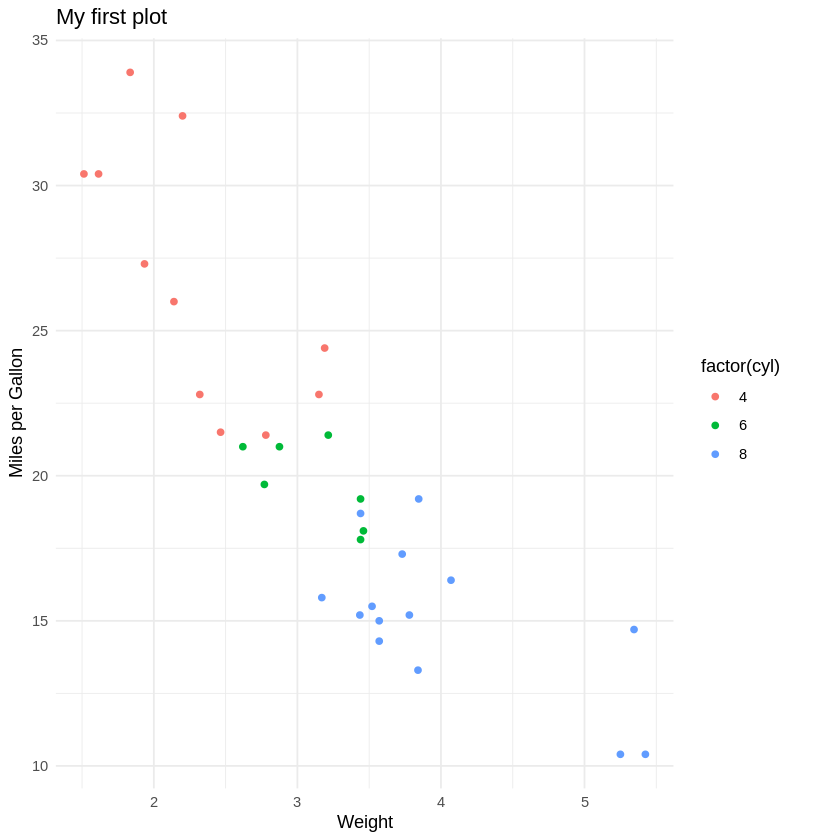

In [18]:
ggplot(mtcars,aes(x=wt,y=mpg,color=factor(cyl)))+
  geom_point()+
  labs(title="My first plot",x="Weight",y="Miles per Gallon")+
  theme_minimal()

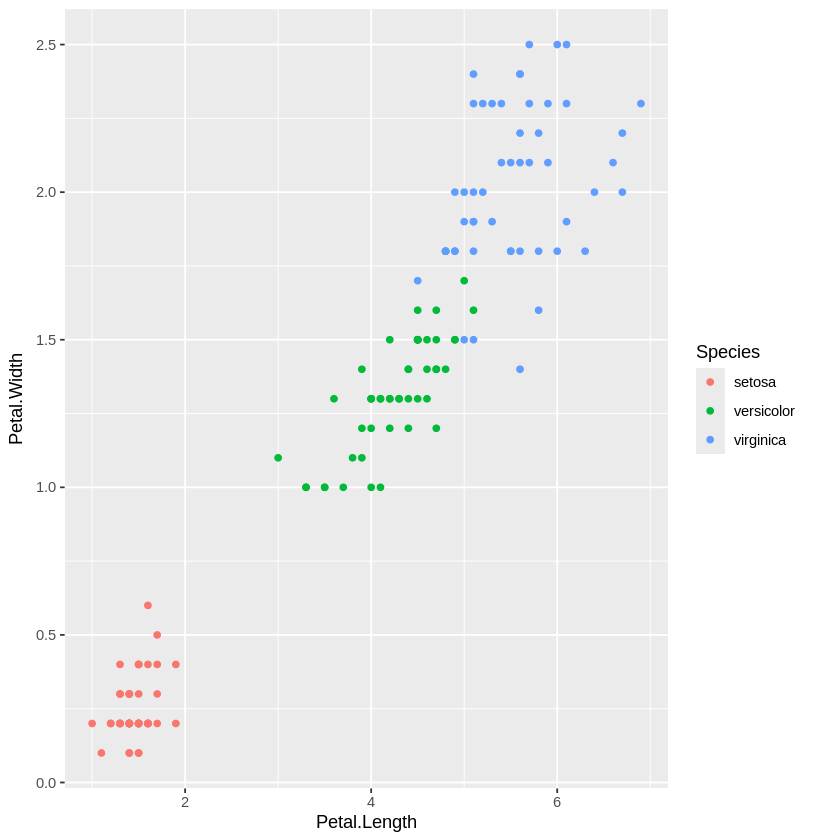

In [13]:
ggplot(iris, aes(x=Petal.Length,y=Petal.Width, color=Species)) + geom_point()

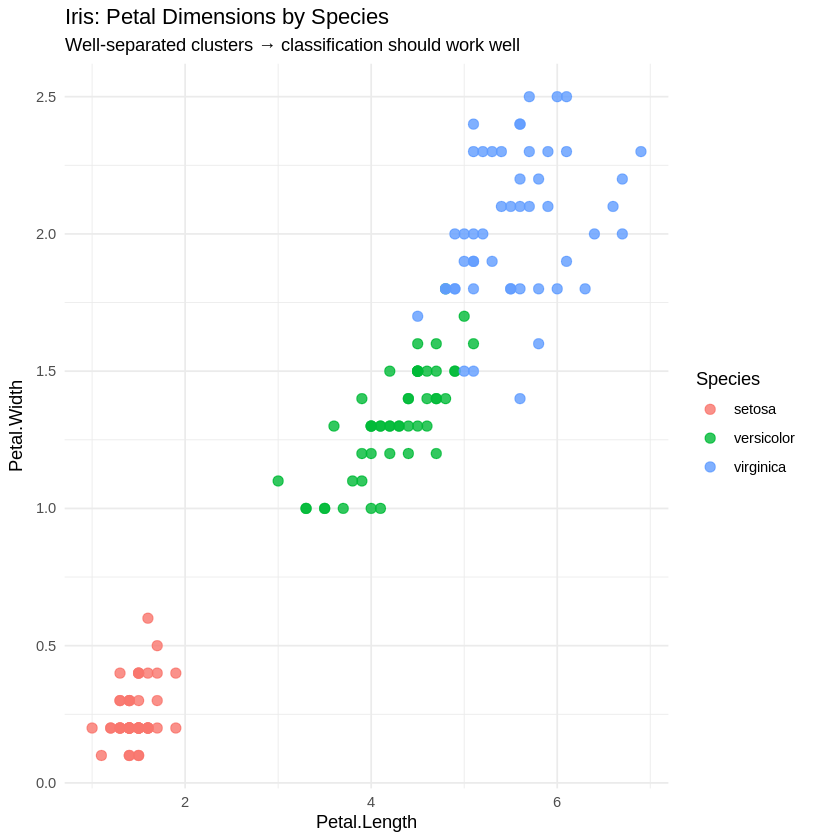

In [8]:
ggplot(iris, aes(x = Petal.Length, y = Petal.Width, color = Species)) +
  geom_point(size = 2.5, alpha = 0.8) +
  labs(title = "Iris: Petal Dimensions by Species",
       subtitle = "Well-separated clusters → classification should work well") +
  theme_minimal()

### **Step 2: Train/test split**

In [ ]:
set.seed(42)   # reproducibility — always set a seed!

train_idx  <- sample(1:nrow(iris), size = 0.75 * nrow(iris))
train_data <- iris[ train_idx, ]
test_data  <- iris[-train_idx, ]

cat("Training samples:", nrow(train_data), "\n")
cat("Test samples:    ", nrow(test_data), "\n")

### **Step 3: Train a decision tree**

In [ ]:
# Decision trees: human-readable, no black box
tree_model <- rpart(Species ~ ., data = train_data, method = "class")

# Visualize the tree — this is R's superpower for explainability
rpart.plot(tree_model,
           type = 4, extra = 104,
           box.palette = "RdYlGn",
           main = "Decision Tree: Iris Classification")

### **Step 4: Predict and evaluate**

In [ ]:
predictions <- predict(tree_model, test_data, type = "class")

# Confusion matrix — rows = actual, cols = predicted
conf_matrix <- table(Actual = test_data$Species, Predicted = predictions)
conf_matrix

# Overall accuracy
accuracy <- mean(predictions == test_data$Species)
cat(sprintf("\nAccuracy: %.1f%%\n", accuracy * 100))

### **Step 5: Interpret the results**

```
Looking at the confusion matrix:
- Perfect classification of setosa (100%)  
- A few versicolor/virginica confusions (these species overlap in petal size)
- Overall ~95% accuracy
```

> **Why this matters:** AI can generate all the code above in seconds.
> What AI *cannot* do is tell you whether 95% accuracy is good *for your use case*,
> whether your train/test split might have data leakage, or whether a decision tree
> is the right model for your domain constraints.

---

# **8 · Working with AI: Prompting, Verifying, Fixing**

This is the section that makes everything else in this workshop more useful.

## **The AI-R collaboration workflow**

```
You describe goal → AI writes code → You run & read output
→ You verify logic → You ask AI to fix/explain → Repeat
```

## **How to write good prompts for R code**

### ❌ **Vague prompt**
> "Write R code to analyze my data"

### ✅ **Specific prompt**
> "I have an R data frame called `patient_df` with columns: `age` (numeric),
> `treatment` (character: 'A' or 'B'), and `outcome` (numeric, 0–100).
> Write dplyr code to compute the mean and standard deviation of `outcome`
> grouped by `treatment`, and then a ggplot2 boxplot comparing the two groups.
> Use theme_minimal()."

**The better your prompt describes your data structure and goal,
the more accurate the generated code will be.**

---

## **Live demo: AI-assisted debugging**

Run this intentionally broken code, then use AI to fix it.

In [ ]:
bad_df <- data.frame(x = 1:5, y = c(2, 4, NA, 8, 10))

bad_df %>%
  filter(x > 2) %>%
  summarize(mean_y = mean(y, na.rm = TRUE))

In [ ]:
# ── FIXED VERSION (fill in after AI helps you) ──

bad_df <- data.frame(x = 1:5, y = c(2, 4, NA, 8, 10))

# Your corrected code here:
bad_df %>%
  filter(x > 2) %>%
  summarize(mean_y = mean(y, na.rm = TRUE))

## **Common AI code review checklist**

Before using AI-generated R code, verify:

- [ ] **Does it run?** — Paste and execute; don't assume it works
- [ ] **Are the variable names right?** — AI sometimes invents column names
- [ ] **Is `na.rm = TRUE` needed?** — AI often forgets missing value handling
- [ ] **Is the package loaded?** — AI often uses functions without loading the library
- [ ] **Is the method appropriate?** — AI picks common methods, not necessarily the *right* one
- [ ] **Does the result match expectations?** — Sanity-check with `summary()` and a plot
- [ ] **Are you sharing private data?** — Never paste real patient/proprietary data into AI tools

---

## **What AI is genuinely great at**

| Task | Example prompt |
|---|---|
| Explaining code | "Explain this R function line by line" |
| Fixing errors | "Fix this error: `Error in ...: object not found`" |
| Finding packages | "What R package should I use for survival analysis?" |
| Code style | "Rewrite this for-loop using dplyr" |
| Plot polish | "Make this ggplot2 plot publication-ready with larger fonts" |
| Documentation | "Add comments to this R script explaining what each section does" |

---

## 🔬 **Final exercise: Full AI-assisted workflow**

**Task:** Using the World Happiness dataset, answer a real research question with AI assistance.

In [ ]:
# Download the data
url <- "https://raw.githubusercontent.com/ajaypalsinghlo/World-Happiness-Report/main/world-happiness-report.csv"
# (If URL is unavailable, use: data(mtcars) and adapt the exercise)

# Suggested workflow:
# 1. Load the data with read.csv()
# 2. Use str() and summary() to understand its structure
# 3. Ask AI: "Given this data structure: [paste str() output],
#             write dplyr + ggplot2 code to show how average
#             happiness score changed over time by region"
# 4. Run the AI code, check for errors, fix with AI help
# 5. Interpret the result — what does it actually mean?

# Your code here:

# **9. Wrap-Up: Key Takeaways**

---

## **What you can now do**
1. **Read and write** R syntax, data structures, and dplyr/ggplot2 code
2. **Understand** AI-generated R code instead of copy-pasting blindly
3. **Debug** errors using both R skills and AI assistance
4. **Run** a complete ML workflow: load → explore → train → evaluate
5. **Ask** AI effective, specific prompts for R tasks

## **Where to go next**

| Goal | Resource |
|---|---|
| R fundamentals reference | [R for Data Science (free online)](https://r4ds.had.co.nz) |
| ggplot2 | [ggplot2 cheatsheet (Posit)](https://posit.co/resources/cheatsheets/) |
| Statistics in R | [Modern Statistics with R](https://www.modernstatisticswithr.com) |
| Machine learning in R | [Hands-On Machine Learning with R (free)](https://bradleyboehmke.github.io/HOML/) |
| HPC + R at LONI | [hpc.loni.org/training](https://hpc.loni.org/training) |
| Parallel R on SLURM | Ask your HPC support team — `doParallel` + `foreach` on multi-core nodes |

## **Running R on HPC**
Your analyses rarely stay small. When they grow:
- Submit R scripts as SLURM batch jobs
- Use `doParallel` / `foreach` for embarrassingly parallel tasks
- Use `Rscript` from the command line: `Rscript my_analysis.R`
- Load R via Lmod: `module load R`

---

*Workshop prepared for LONI/LSU HPC — Summer 2026*  
*Feedback: sys-help@loni.org*